In [1]:
import matplotlib.pyplot as plt

# Configure matplotlib for editable text in Inkscape SVG exports
plt.rcParams.update({'text.usetex': False, 'svg.fonttype': 'none'})

In [2]:
import pandas as pd

# Load the Excel file, specifying the second sheet (index 1)
try:
    oh_table = pd.read_excel('/content/oh_table1.xls', sheet_name=1)
    print("Excel file 'oh_table1.xls' loaded successfully from the second sheet.")
    display(oh_table.head())
except FileNotFoundError:
    print("Error: 'oh_table1.xls' not found. Please ensure the file is uploaded to /content/.")
except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")

Excel file 'oh_table1.xls' loaded successfully from the second sheet.


,ID,Ontology order,Acronym,Name,Major Region,Voxel Count,Structure Hit with rAAV?,Primary Inj Site,Secondary Inj Site,Represented in Linear Model Matrix,...,Unnamed: 16,DMN,salience,ul,ll-tr,eye,face,whisker,medial,lateral
0,1017.0,954.0,AN,Ansiform lobule,Cerebellar Cortex,9044.0,Yes,Yes,NaN,NaN,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,928.0,916.0,CUL,Culmen,Cerebellar Cortex,6635.0,Yes,Yes,NaN,NaN,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1041.0,971.0,PFL,Paraflocculus,Cerebellar Cortex,5283.0,Yes,Yes,NaN,NaN,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1007.0,950.0,SIM,Simple lobule,Cerebellar Cortex,5218.0,Yes,Yes,NaN,NaN,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,920.0,907.0,CENT,Central lobule,Cerebellar Cortex,3839.0,Yes,Yes,NaN,NaN,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
import dill

def load_pickled_dict(filepath):
    filepath = filepath.split('.pkl')[0] + ".pkl"
    with open(filepath, "rb") as f:
        d = dill.load(f)
    return d

In [4]:
path = './tvb_serial_cosimulator.pkl'
sim = load_pickled_dict(path)

Using 'Major Region' column for primary region classification.
Refined region mapping created from oh_table. Now updating the summarizer function with new user requests. Re-running summarization to ensure changes are applied.


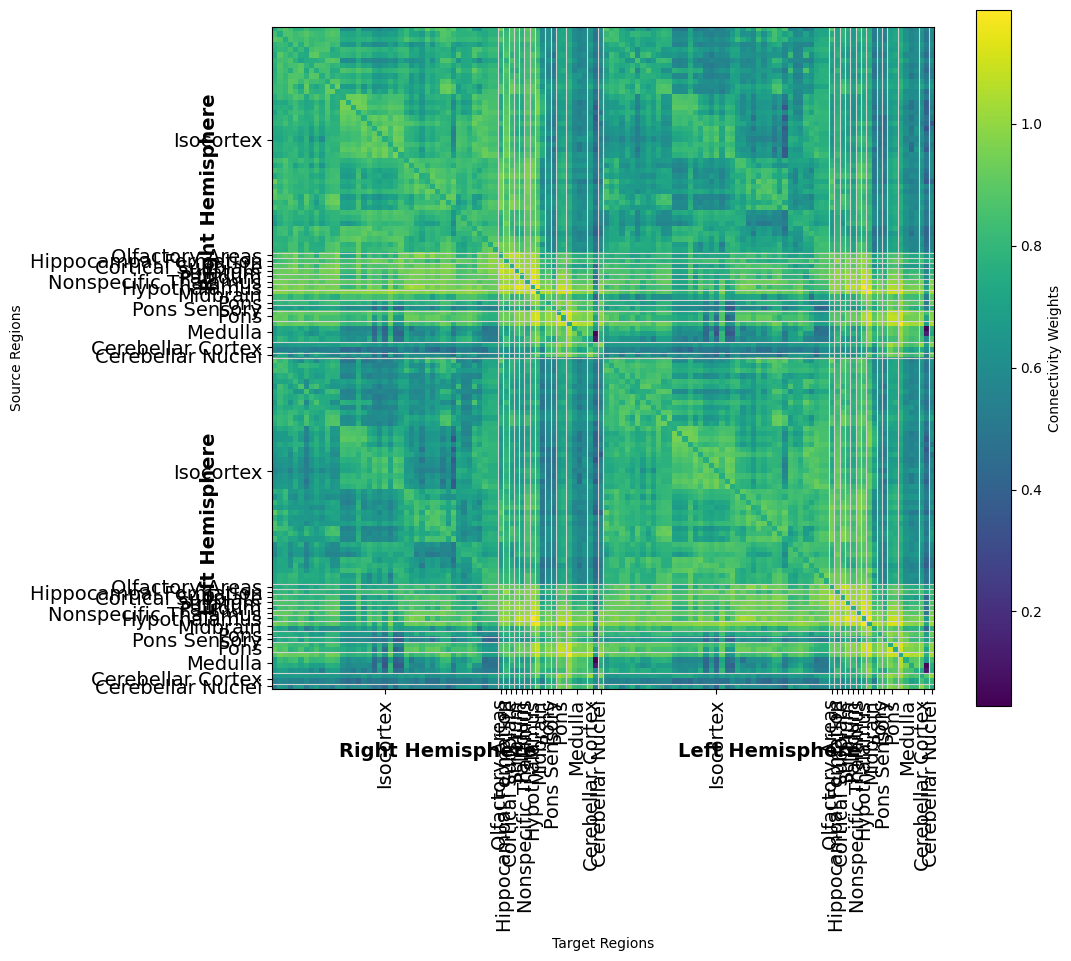

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import re
from collections import Counter
import pandas as pd # Ensure pandas is imported for pd.notna

# Initialize the refined_region_map
refined_region_map = {}
major_region_column_used = False # Flag to indicate if 'Major Region' column was successfully used

unique_major_region_values = set() # To store lowercase unique major region names
major_region_original_casing_map = {} # To store original casing of major region names

if 'Major Region' in oh_table.columns:
    major_region_column_used = True
    print("Using 'Major Region' column for primary region classification.")

    # Populate unique_major_region_values and major_region_original_casing_map
    for val in oh_table['Major Region'].unique():
        if pd.notna(val): # Exclude NaN values
            cleaned_val = str(val).strip().lower()
            unique_major_region_values.add(cleaned_val)
            major_region_original_casing_map[cleaned_val] = str(val).strip()

    for index, row in oh_table.iterrows():
        major_region = str(row['Major Region']).strip() # Ensure it's string and clean whitespace

        # Clean the 'Name' from the oh_table for consistent matching
        cleaned_oh_name = str(row['Name']).lower().replace('_', ' ').strip()
        if major_region: # Only map if Major Region is not empty
            refined_region_map[cleaned_oh_name] = major_region

        # Also map acronyms if they exist and are different
        cleaned_oh_acronym = str(row['Acronym']).lower().strip()
        if cleaned_oh_acronym and cleaned_oh_acronym != cleaned_oh_name and major_region:
            refined_region_map[cleaned_oh_acronym] = major_region
else:
    print("Warning: 'Major Region' column not found in oh_table. Falling back to keyword-based classification for refined_region_map.")
    # This block populates refined_region_map using keywords, similar to the original code
    for index, row in oh_table.iterrows():
        cleaned_oh_name = row['Name'].lower().replace('_', ' ').strip()

        if 'isocortex' in cleaned_oh_name:
            refined_region_map[cleaned_oh_name] = 'Isocortex'
        elif 'cerebellum' in cleaned_oh_name:
            refined_region_map[cleaned_oh_name] = 'Cerebellum'
        elif any(sub_keyword in cleaned_oh_name for sub_keyword in ['thalamus', 'hippocampus', 'amygdala', 'brainstem', 'putamen', 'pallidum', 'caudate', 'diencephalon', 'subiculum']):
            refined_region_map[cleaned_oh_name] = 'Subcortex'
        else:
            refined_region_map[cleaned_oh_name] = row['Name'] # Default to its own Name

        cleaned_oh_acronym = row['Acronym'].lower().strip()
        if cleaned_oh_acronym and cleaned_oh_acronym != cleaned_oh_name:
            if 'isocortex' in cleaned_oh_acronym:
                refined_region_map[cleaned_oh_acronym] = 'Isocortex'
            elif 'cerebellum' in cleaned_oh_acronym:
                refined_region_map[cleaned_oh_acronym] = 'Cerebellum'
            elif any(sub_keyword in cleaned_oh_acronym for sub_keyword in ['thalamus', 'hippocampus', 'amygdala', 'brainstem', 'putamen', 'pallidum', 'caudate', 'diencephalon', 'subiculum']):
                refined_region_map[cleaned_oh_acronym] = 'Subcortex'
            else:
                refined_region_map[cleaned_oh_acronym] = row['Name']

print("Refined region mapping created from oh_table. Now updating the summarizer function with new user requests. Re-running summarization to ensure changes are applied.")

# Function to aggressively summarize region labels
def aggressive_region_summarizer(label):
    # Remove hemisphere prefixes (e.g., 'Left-', 'Right-', 'Left ', 'Right ')
    cleaned_label = re.sub(r'^(Left|Right)[\s-]', '', label)
    # Replace underscores with spaces
    cleaned_label = cleaned_label.replace('_', ' ')
    # Lowercase for consistent matching
    cleaned_label = cleaned_label.lower()

    # --- NEW USER REQUESTS (takes precedence) ---
    # Consolidate 'Pons' regions to a single 'Pons' label
    if 'pons' in cleaned_label:
        return 'Pons'
    # Consolidate 'Spinal nucleus of the trigeminal' to 'Medulla'
    if 'spinal nucleus of the trigeminal' in cleaned_label:
        return 'Medulla'
    # --- END NEW USER REQUESTS ---

    # Try to match with the refined_region_map from oh_table
    if cleaned_label in refined_region_map:
        return refined_region_map[cleaned_label]

    # --- Conditional Fallback Logic ---
    if major_region_column_used:
        # NEW: Check if the cleaned label itself matches a unique major region value
        if cleaned_label in unique_major_region_values:
            return major_region_original_casing_map[cleaned_label]
        # If 'Major Region' column was present and used, and a label didn't map
        # and isn't itself a major region value, then it's 'Other Major Region'.
        return 'Other Major Region'
    else:
        # If 'Major Region' column was NOT present, then the refined_region_map was built
        # using the original keyword logic (e.g., 'isocortex' in name -> 'Isocortex').
        # The internal keyword checks below serve as a further layer of classification
        # if the simple `refined_region_map` lookup didn't yield a result.
        # This is the original behavior when 'Major Region' is not available.

        isocortical_keywords = [
            'motor cortex', 'somatosensory cortex', 'frontal lobe', 'temporal lobe',
            'parietal lobe', 'occipital lobe', 'cingulate cortex', 'insula',
            'visual cortex', 'auditory cortex', 'retrosplenial cortex', 'orbital cortex',
            'piriform cortex', 'medial prefrontal cortex', 'fusiform gyrus', 'parahippocampal gyrus',
            'precentral gyrus', 'postcentral gyrus', 'supramarginal gyrus', 'angular gyrus',
            'precuneus', 'lingual gyrus', 'calcarine cortex'
        ]
        subcortical_keywords = [
            'hippocampus', 'amygdala', 'putamen', 'pallidum', 'caudate',
            'thalamus', 'brainstem', 'diencephalon', 'subiculum'
        ]
        cerebellar_keywords = ['cerebell']

        if any(keyword in cleaned_label for keyword in isocortical_keywords):
            return 'Isocortex'
        elif any(keyword in cleaned_label for keyword in subcortical_keywords):
            return 'Subcortex'
        elif any(keyword in cleaned_label for keyword in cerebellar_keywords):
            return 'Cerebellum'
        else:
            # Fallback for anything not explicitly categorized by keywords
            return 'Isocortex' # Original default fallback.

is_thalamic = sim["coupling.is_thalamic"].flatten()
initial_non_thalamic_indices = np.where(~is_thalamic)[0]

all_region_labels = sim["connectivity.region_labels"]

# Identify ONLY 'Right Whiskers' and 'Left Whiskers' to exclude
# Note: This will not exclude 'barrel field' regions unless they explicitly contain 'whiskers'
whisker_region_keywords = ['right whiskers', 'left whiskers']
whisker_indices_to_exclude = []
for i, label in enumerate(all_region_labels):
    if any(keyword in label.lower() for keyword in whisker_region_keywords):
        whisker_indices_to_exclude.append(i)

# Filter non_thalamic_indices to exclude specifically identified whisker regions
non_thalamic_indices = [idx for idx in initial_non_thalamic_indices if idx not in whisker_indices_to_exclude]
non_thalamic_indices = np.array(non_thalamic_indices) # Convert back to numpy array

# Recalculate filtered_weights, non_thalamic_full_labels and summarized_non_thalamic_labels based on the new non_thalamic_indices
filtered_weights = sim["connectivity.weights"][np.ix_(non_thalamic_indices, non_thalamic_indices)]

# Filter and summarize labels for non-thalamic nodes
non_thalamic_full_labels = [all_region_labels[i] for i in non_thalamic_indices]
summarized_non_thalamic_labels = [aggressive_region_summarizer(label) for label in non_thalamic_full_labels]

num_non_thalamic = len(non_thalamic_indices)

# --- New code to identify hemisphere boundaries (updated) ---
right_indices_all = []
left_indices_all = []
for i, label in enumerate(non_thalamic_full_labels):
    if label.startswith('Right '):
        right_indices_all.append(i)
    elif label.startswith('Left '):
        left_indices_all.append(i)

# --- Reverting the Medulla reordering ---
# The previous reordering block has been removed. The labels and weights are now
# in their original order after filtering for thalamic and whisker regions.
# Recalculate hemisphere boundaries for the reordered data
right_indices_all = []
left_indices_all = []
for i, label in enumerate(non_thalamic_full_labels): # Use the newly ordered labels
    if label.startswith('Right '):
        right_indices_all.append(i)
    elif label.startswith('Left '):
        left_indices_all.append(i)

# Now define the ranges for plotting purposes, if contiguous
first_left_index_in_filtered = -1
if left_indices_all: # If there are left regions
    first_left_index_in_filtered = left_indices_all[0]

right_start, right_end = -1, -1
left_start, left_end = -1, -1

if first_left_index_in_filtered != -1:
    if first_left_index_in_filtered > 0: # Means there are Right regions before Left
        right_start = 0
        right_end = first_left_index_in_filtered - 1
        left_start = first_left_index_in_filtered
        left_end = num_non_thalamic - 1
    else: # All are Left (which implies first_left_index_in_filtered is 0)
        left_start = 0
        left_end = num_non_thalamic - 1
else: # All are Right
    right_start = 0
    right_end = num_non_thalamic - 1

# --- Plotting code modifications ---
plt.figure(figsize=(14, 12)) # Increased figure size for better label readability and space for new labels
ax = plt.gca() # Get current axes

# Create a copy to avoid modifying the original filtered_weights if it's used elsewhere
modified_weights = np.copy(filtered_weights)

# Create a mask for non-diagonal elements
non_diag_mask = ~np.eye(num_non_thalamic, dtype=bool)

# Calculate the average of all non-diagonal displayed values
average_non_diag_weight = np.mean(modified_weights[non_diag_mask])

# Replace diagonal elements with this average
np.fill_diagonal(modified_weights, average_non_diag_weight)

im = ax.imshow(modified_weights, cmap='viridis')
plt.colorbar(im, label='Connectivity Weights')

# --- New logic for unique summarized labels and their ranges ---
unique_labels_info = [] # Stores (label, start_idx, end_idx)
current_label = None
current_start_idx = 0

for i, label in enumerate(summarized_non_thalamic_labels):
    if label != current_label:
        if current_label is not None:
            unique_labels_info.append((current_label, current_start_idx, i - 1))
        current_label = label
        current_start_idx = i
unique_labels_info.append((current_label, current_start_idx, num_non_thalamic - 1)) # Add the last block

# --- MODIFICATION START ---
# Remove the filtering by top 12 labels to display all unique summarized labels
new_xticks = []
new_xticklabels = []
new_yticks = []
new_yticklabels = []

for label, start_idx, end_idx in unique_labels_info:
    center_idx = (start_idx + end_idx) / 2.0
    new_xticks.append(center_idx)
    new_xticklabels.append(label)
    new_yticks.append(center_idx)
    new_yticklabels.append(label)
# --- MODIFICATION END ---

# Set ticks and labels for individual regions
ax.set_xticks(new_xticks)
ax.set_xticklabels(new_xticklabels, rotation=90, fontsize=14) # Decreased fontsize for potentially more labels
ax.set_yticks(new_yticks)
ax.set_yticklabels(new_yticklabels, fontsize=14) # Decreased fontsize for potentially more labels

#plt.title('Connectivity Weights (Excluding Thalamic and Specific Whiskers Nodes) with Summarized Region and Hemisphere Labels')
plt.xlabel('Target Regions')
plt.ylabel('Source Regions')

# Add hemisphere labels and separating lines
# Adjust position based on actual plot limits to ensure visibility
y_offset_x_axis = ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.08 # Position text below x-axis
x_offset_y_axis = ax.get_xlim()[0] - (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.08 # Position text left of y-axis

if right_start != -1 and right_end != -1:
    right_center_x = (right_start + right_end) / 2
    right_center_y = (right_start + right_end) / 2

    # X-axis (target regions) - Right Hemisphere
    ax.text(right_center_x, y_offset_x_axis, 'Right Hemisphere', ha='center', va='top',
            fontsize=14, fontweight='bold', transform=ax.transData, clip_on=False)
    # Y-axis (source regions) - Right Hemisphere
    ax.text(x_offset_y_axis, right_center_y, 'Right Hemisphere', ha='right', va='center',
            fontsize=14, fontweight='bold', transform=ax.transData, rotation=90, clip_on=False)

if left_start != -1 and left_end != -1:
    left_center_x = (left_start + left_end) / 2
    left_center_y = (left_start + left_end) / 2

    # X-axis (target regions) - Left Hemisphere
    ax.text(left_center_x, y_offset_x_axis, 'Left Hemisphere', ha='center', va='top',
            fontsize=14, fontweight='bold', transform=ax.transData, clip_on=False)
    # Y-axis (source regions) - Left Hemisphere
    ax.text(x_offset_y_axis, left_center_y, 'Left Hemisphere', ha='right', va='center',
            fontsize=14, fontweight='bold', transform=ax.transData, rotation=90, clip_on=False)

# Adding lines to delineate hemispheres if both are present
if first_left_index_in_filtered != -1 and first_left_index_in_filtered > 0:
    # Vertical line for X-axis (target regions)
    ax.axvline(first_left_index_in_filtered - 0.5, color='gray', linestyle='--', linewidth=1)
    # Horizontal line for Y-axis (source regions)
    ax.axhline(first_left_index_in_filtered - 0.5, color='gray', linestyle='--', linewidth=1)

# Add lines to delineate summarized regions
for _, _, end_idx in unique_labels_info[:-1]: # Exclude the last region as it doesn't have a trailing line
    ax.axvline(end_idx + 0.5, color='lightgray', linestyle='-', linewidth=0.8) # Vertical line
    ax.axhline(end_idx + 0.5, color='lightgray', linestyle='-', linewidth=0.8) # Horizontal line

plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9]) # Adjust layout to prevent labels from being cut off
plt.show()

In [7]:
import numpy as np
from matplotlib import pyplot as plt

def second_level_summarizer(label_from_first_level):
    label_lower = label_from_first_level.lower()

    if label_lower == 'isocortex':
        return 'Isocortex'
    elif 'cerebellar' in label_lower or label_lower == 'cerebellum':
        return 'Cereb'
    # Consolidate all other identified subcortical regions into 'Subcortex'
    elif label_lower in ['olfactory areas', 'hippocampal formation', 'cortical subplate',
                         'striatum', 'pallidum', 'nonspecific thalamus', 'hypothalamus',
                         'midbrain', 'pons', 'medulla', 'other major region', 'pons sensory', 'pons behavioral', 'pons motor']:
        return 'Subcortex'
    else:
        # As a fallback, if any other label comes through, retain it.
        # This should ideally not be hit if the lists above are comprehensive for the first-level summary labels.
        return label_from_first_level

# Apply the second level summarization to the already summarized labels
second_level_summarized_labels = [second_level_summarizer(label) for label in summarized_non_thalamic_labels]

# --- New logic for unique second-level summarized labels and their ranges ---
second_level_unique_labels_info = [] # Stores (label, start_idx, end_idx)
current_label = None
current_start_idx = 0

for i, label in enumerate(second_level_summarized_labels):
    if label != current_label:
        if current_label is not None:
            second_level_unique_labels_info.append((current_label, current_start_idx, i - 1))
        current_label = label
        current_start_idx = i
second_level_unique_labels_info.append((current_label, current_start_idx, num_non_thalamic - 1)) # Add the last block

print(f"Second level summarization applied. New unique labels: {[info[0] for info in second_level_unique_labels_info]}")

Second level summarization applied. New unique labels: ['Isocortex', 'Subcortex', 'Cereb', 'Isocortex', 'Subcortex', 'Cereb']


In [ ]:
plt.figure(figsize=(14, 12))
ax = plt.gca()

# Create a copy to avoid modifying the original filtered_weights if it's used elsewhere
# 'modified_weights' is already available from previous execution if not. Copy 'filtered_weights'.
modified_weights_second_level = np.copy(filtered_weights)

# Create a mask for non-diagonal elements
non_diag_mask = ~np.eye(num_non_thalamic, dtype=bool)

# Calculate the average of all non-diagonal displayed values
average_non_diag_weight = np.mean(modified_weights_second_level[non_diag_mask])

# Replace diagonal elements with this average
np.fill_diagonal(modified_weights_second_level, average_non_diag_weight)

im = ax.imshow(modified_weights_second_level, cmap='viridis')
# Adjust colorbar to have the same height as the matrix
cbar = plt.colorbar(im, label='Connectivity', shrink=0.9) # Changed shrink to 1.0
cbar.set_label('Connectivity', fontsize=14) # Set colorbar label fontsize
cbar.ax.tick_params(labelsize=14) # Optional: Set colorbar tick labels fontsize, increased to 12

# --- Plotting with second_level_unique_labels_info ---
new_xticks_second_level = []
new_xticklabels_second_level = []
new_yticks_second_level = []
new_yticklabels_second_level = []

for label, start_idx, end_idx in second_level_unique_labels_info:
    center_idx = (start_idx + end_idx) / 2.0
    new_xticks_second_level.append(center_idx)
    new_xticklabels_second_level.append(label)
    new_yticks_second_level.append(center_idx)
    new_yticklabels_second_level.append(label)

# Define rotation for y-axis labels based on content
rotation_list_y = []
for label in new_yticklabels_second_level:
    if label == 'Cereb':
        rotation_list_y.append(0) # Orthogonal (horizontal)
    else:
        rotation_list_y.append(90)

# Define rotation for x-axis labels based on content
rotation_list_x = []
for label in new_xticklabels_second_level:
    if label == 'Cereb':
        rotation_list_x.append(90) # Changed to 90 degrees for Cereb
    else:
        rotation_list_x.append(0) # Changed to 0 degrees for others

ax.set_xticks(new_xticks_second_level)
# Iterate and set x-tick labels rotation individually
xt_labels = ax.set_xticklabels(new_xticklabels_second_level, ha='center', fontsize=14)
for i, text_label in enumerate(xt_labels):
    text_label.set_rotation(rotation_list_x[i])

ax.set_yticks(new_yticks_second_level)

# Iterate and set y-tick labels rotation individually
# Y-axis labels: 'Cereb' orthogonal, others rotated 90 degrees
yt_labels = ax.set_yticklabels(new_yticklabels_second_level, va='center', fontsize=14)
for i, text_label in enumerate(yt_labels):
    text_label.set_rotation(rotation_list_y[i])

#plt.title('Connectivity Weights (Second Level Summarization - Excluding Thalamic and Specific Whiskers Nodes)')
#plt.xlabel('Target Regions')
#plt.ylabel('Source Regions')

# Add hemisphere labels and separating lines (using same logic as before)
y_offset_x_axis = ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.08
x_offset_y_axis = ax.get_xlim()[0] - (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.08

# Bring back hemisphere labels, without bold font
if right_start != -1 and right_end != -1:
    right_center_x = (right_start + right_end) / 2
    right_center_y = (right_start + right_end) / 2
    ax.text(right_center_x, y_offset_x_axis, 'R', ha='center', va='top',
            fontsize=14, transform=ax.transData, clip_on=False)
    ax.text(x_offset_y_axis, right_center_y, 'R', ha='right', va='center',
            fontsize=14, transform=ax.transData, rotation=90, clip_on=False)

if left_start != -1 and left_end != -1:
    left_center_x = (left_start + left_end) / 2
    left_center_y = (left_start + left_end) / 2
    ax.text(left_center_x, y_offset_x_axis, 'L', ha='center', va='top',
            fontsize=14, transform=ax.transData, clip_on=False)
    ax.text(x_offset_y_axis, left_center_y, 'L', ha='right', va='center',
            fontsize=14, transform=ax.transData, rotation=90, clip_on=False)

# Added lines to delineate hemispheres if both are present (keeping these lines)
if first_left_index_in_filtered != -1 and first_left_index_in_filtered > 0:
    ax.axvline(first_left_index_in_filtered - 0.5, color='gray', linestyle='--', linewidth=1)
    ax.axhline(first_left_index_in_filtered - 0.5, color='gray', linestyle='--', linewidth=1)

# Add lines to delineate summarized regions (second level)
for _, _, end_idx in second_level_unique_labels_info[:-1]:
    ax.axvline(end_idx + 0.5, color='lightgray', linestyle='-', linewidth=0.8)
    ax.axhline(end_idx + 0.5, color='lightgray', linestyle='-', linewidth=0.8)

plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])
plt.savefig('conn_matrix.svg', bbox_inches='tight') # Changed to SVG
plt.show()